# Importing packages and functions

In [34]:
%matplotlib inline
# standard libraries
import numpy as np
import scipy as sp
import pandas as pd
import glob,os,re
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# image related libraries
import os
import cv2
from skimage.filters import threshold_otsu
from scipy.ndimage import distance_transform_edt,convolve
import seaborn as sns
import skimage
from skimage.transform import resize
from skimage import io
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
# ML packages 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
# TDA related libraries
import cripser, tcripser
from ripser import ripser
import persim
import gudhi
import PersistenceImages.persistence_images as pimg
from persim.landscapes import PersLandscapeExact
from persim.landscapes import plot_landscape_simple
from persim.landscapes import PersistenceLandscaper
from persim import PersistenceImager
from persim import plot_diagrams

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

In [35]:
### define functions used later
# gaussian kernel for convolution
def gaussian(h,sigma):
    x = np.arange(-h[0],h[0],1)
    y = np.arange(-h[1],h[1],1)
    z = np.arange(-h[2],h[2],1)
    xx, yy,zz = np.meshgrid(x,y,z)
    return(np.exp(-(xx**2 + yy**2 + zz**2)/(2*sigma**2)).astype(np.float32))

# computing the heatmap of cycles with specified birth-death properties
# the heatmap image reveals what kind of image features are captured by PH
def heat_map(img,pd,h=3,sigma=1,min_life = 10,max_life =255,min_birth = 0,max_birth = 255,dimension = 0,life_weighted=True,location='birth'):
  if len(img.shape)==2:
    mx,my=img.shape
    mz = 1
    kernel = gaussian([h,h,1],sigma)
  else:
    mx,my,mz=img.shape
    kernel = gaussian([h,h,h],sigma)

  selected_cycle = np.zeros((mx,my,mz))
  ppd = pd[pd[:,0] == dimension]
  ppd = ppd[min_life < ppd[:,2]-ppd[:,1]]
  ppd = ppd[ppd[:,2]-ppd[:,1] < max_life]
  ppd = ppd[min_birth < ppd[:,1]]
  ppd = ppd[ppd[:,1] < max_birth]
  w = 1
  for c in ppd:
      if location=='birth':
        x,y,z=int(c[3]),int(c[4]),int(c[5])
      else:
        x,y,z=int(c[6]),int(c[7]),int(c[8])
      if life_weighted:
        w = c[2]-c[1]
      #selected_cycle[max(0,x-h):min(mx,x+h),max(0,y-h):min(my,y+h),max(0,z-h):min(mz,z+h)] += w
      selected_cycle[x,y,z] += w
  #print(np.min(selected_cycle),np.max(selected_cycle),np.sum(selected_cycle))
  cycle_conv = convolve(selected_cycle,kernel)
  #print(np.min(cycle_conv),np.max(cycle_conv),np.sum(cycle_conv))
  return(np.squeeze(cycle_conv))

# make binary and apply distance transform
def dt(img,radius=None,signed=False):
    if radius is not None:
      from skimage.filters import rank
      from skimage.morphology import disk, ball
      bw_img = (img >= rank.otsu(img, disk(radius)))
    else:
      bw_img = (img >= threshold_otsu(img))
    dt_img = distance_transform_edt(bw_img)
    if signed:
        dt_img -= distance_transform_edt(~bw_img)
    return(dt_img)

# Loading images

## Load and organise images by magnification

In [36]:
base_path = r"D:\Breast cancer images\BreaKHis_v1\BreaKHis_v1\histology_slides\breast"

main_categories = ["benign", "malignant"]

# Function to load images into separate datasets based on magnification level
def load_images_by_magnification(base_path):
    magnifications = {"40X": [], "100X": [], "200X": [], "400X": []}
    labels = {"40X": [], "100X": [], "200X": [], "400X": []}

    # Loop over benign and malignant folders
    for label_idx, category in enumerate(main_categories):  
        category_path = os.path.join(base_path, category, "SOB")
        diagnosis_folders = os.listdir(category_path)
        
        # Loop through each diagnosis folder
        for diagnosis in diagnosis_folders:
            diagnosis_path = os.path.join(category_path, diagnosis)
            patient_folders = os.listdir(diagnosis_path)
            
            # Loop through each patient folder
            for patient in patient_folders:
                patient_path = os.path.join(diagnosis_path, patient)
                magnification_folders = os.listdir(patient_path)
                
                # Loop through each magnification level
                for mag in magnification_folders:
                    if mag not in magnifications:
                        continue  # Skip folders that are not magnifications we expect
                    
                    mag_path = os.path.join(patient_path, mag)
                    image_files = os.listdir(mag_path)
                    
                    # Load images for this magnification
                    for img_file in image_files:
                        img_path = os.path.join(mag_path, img_file)
                        img = load_img(img_path, target_size=(150, 150), color_mode='grayscale')
                        
                        if img is not None:  # Ensure the image was read correctly
                            img_array = img_to_array(img).squeeze() / 255.0  # Normalize
                            magnifications[mag].append(img_array)
                            labels[mag].append(label_idx)  # 0 = benign, 1 = malignant
                            
    return magnifications, labels

def display_random_images(images, labels, magnification, n=5):
    indices = np.random.choice(len(images), n, replace=False)
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        plt.subplot(1, n, i + 1)
        plt.imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
        plt.title(f"Label: {labels[idx]} (0=Benign, 1=Malignant)")
        plt.axis("off")
    plt.suptitle(f"Random Images - Magnification {magnification}")
    plt.tight_layout()
    plt.show()

Loading images by magnification...
Magnification: 40X
Total Images: 1995
Labels Distribution: (array([0, 1]), array([ 625, 1370], dtype=int64))

Magnification: 100X
Total Images: 2071
Labels Distribution: (array([0, 1]), array([ 634, 1437], dtype=int64))

Magnification: 200X
Total Images: 2013
Labels Distribution: (array([0, 1]), array([ 623, 1390], dtype=int64))

Magnification: 400X
Total Images: 1820
Labels Distribution: (array([0, 1]), array([ 588, 1232], dtype=int64))

Displaying random images for 40X...


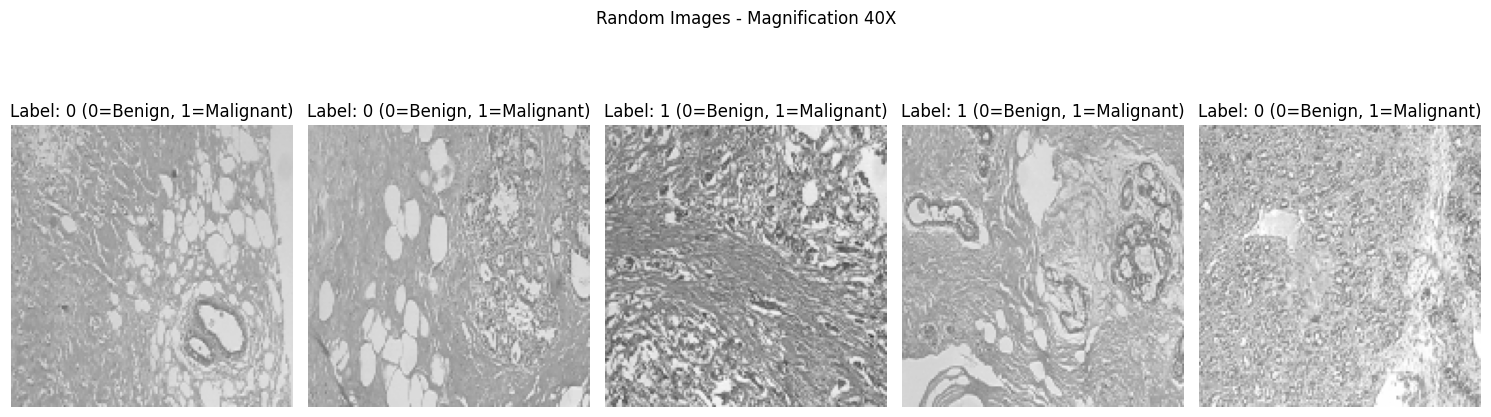

Displaying random images for 100X...


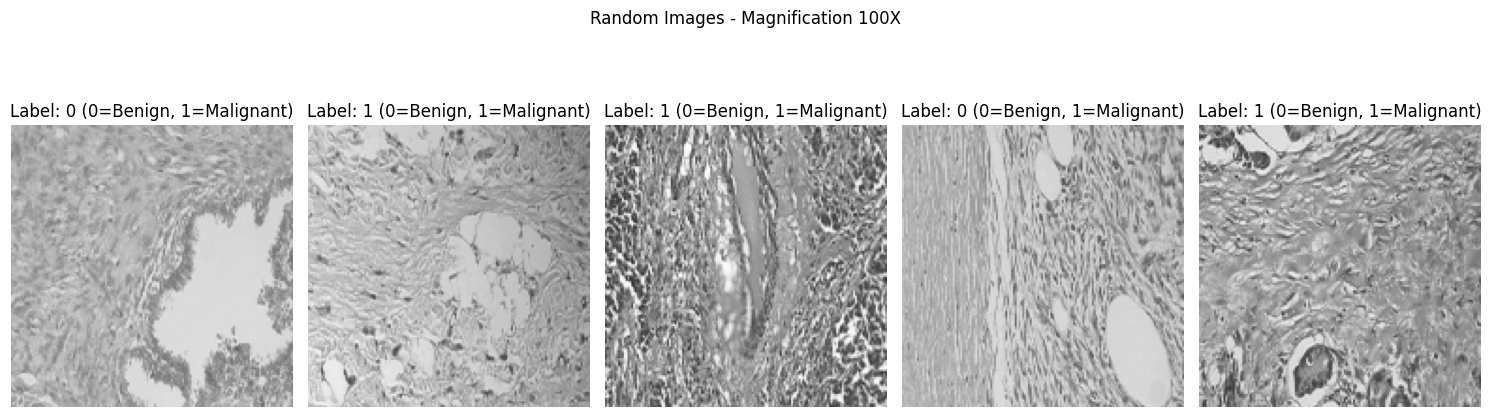

Displaying random images for 200X...


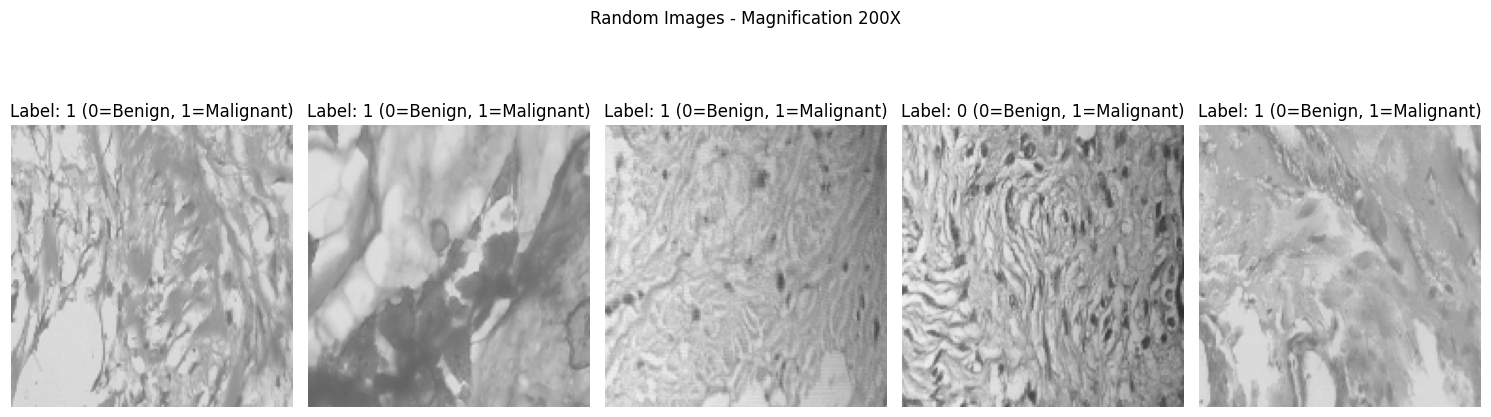

Displaying random images for 400X...


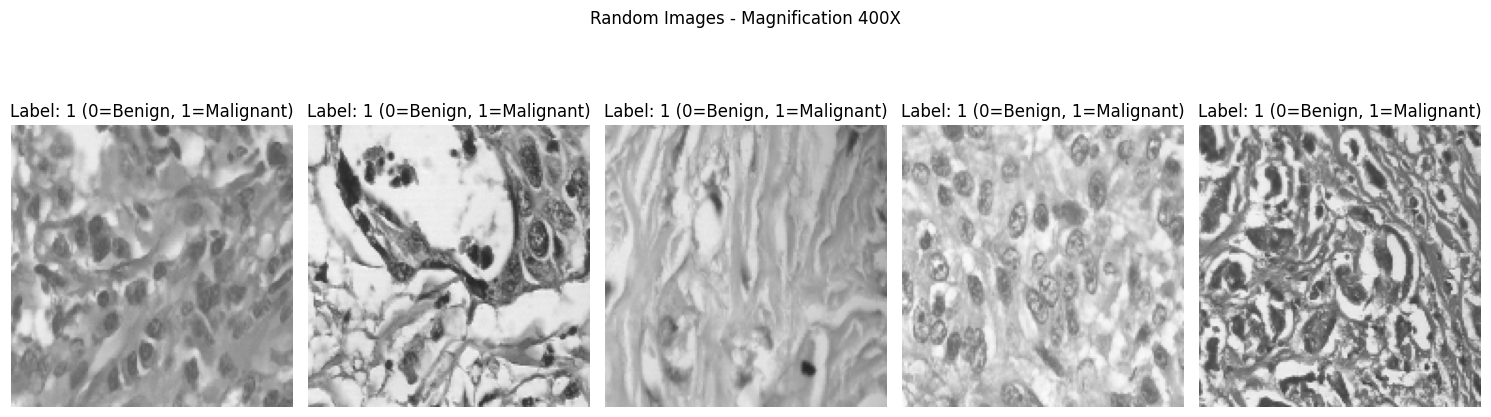

In [37]:
if __name__ == "__main__":
    print("Loading images by magnification...")
    magnification_data, magnification_labels = load_images_by_magnification(base_path)

    # Print dataset summary
    for mag in magnification_data:
        print(f"Magnification: {mag}")
        print(f"Total Images: {len(magnification_data[mag])}")
        print(f"Labels Distribution: {np.unique(magnification_labels[mag], return_counts=True)}\n")

    # Display random images for each magnification level
    for mag in magnification_data:
        print(f"Displaying random images for {mag}...")
        display_random_images(magnification_data[mag], magnification_labels[mag], mag, n=5)

In [38]:
# Access the 40X dataset
X_40X = np.array(magnification_data["40X"])
y_40X = np.array(magnification_labels["40X"])

# Access the 100X dataset
X_100X = np.array(magnification_data["100X"])
y_100X = np.array(magnification_labels["100X"])

# Access the 200X dataset
X_200X = np.array(magnification_data["200X"])
y_200X = np.array(magnification_labels["200X"])

# Access the 400X dataset
X_400X = np.array(magnification_data["400X"])
y_400X = np.array(magnification_labels["400X"])

In [ ]:
pds_40X = []
for i in range(len(X_40X)):
    pd_diagram = cripser.computePH(X_40X[i], maxdim=1)  
    
    pd_diagram = [pd_diagram[pd_diagram[:, 0] == i, 1:3] for i in range(2)]

    pd_diagram_filtered = [
        pd_diagram[i][pd_diagram[i][:, 1] < 1]  # Keep only features where death < 1
        for i in range(2)
    ]
    pds_40X.append(pd_diagram_filtered)

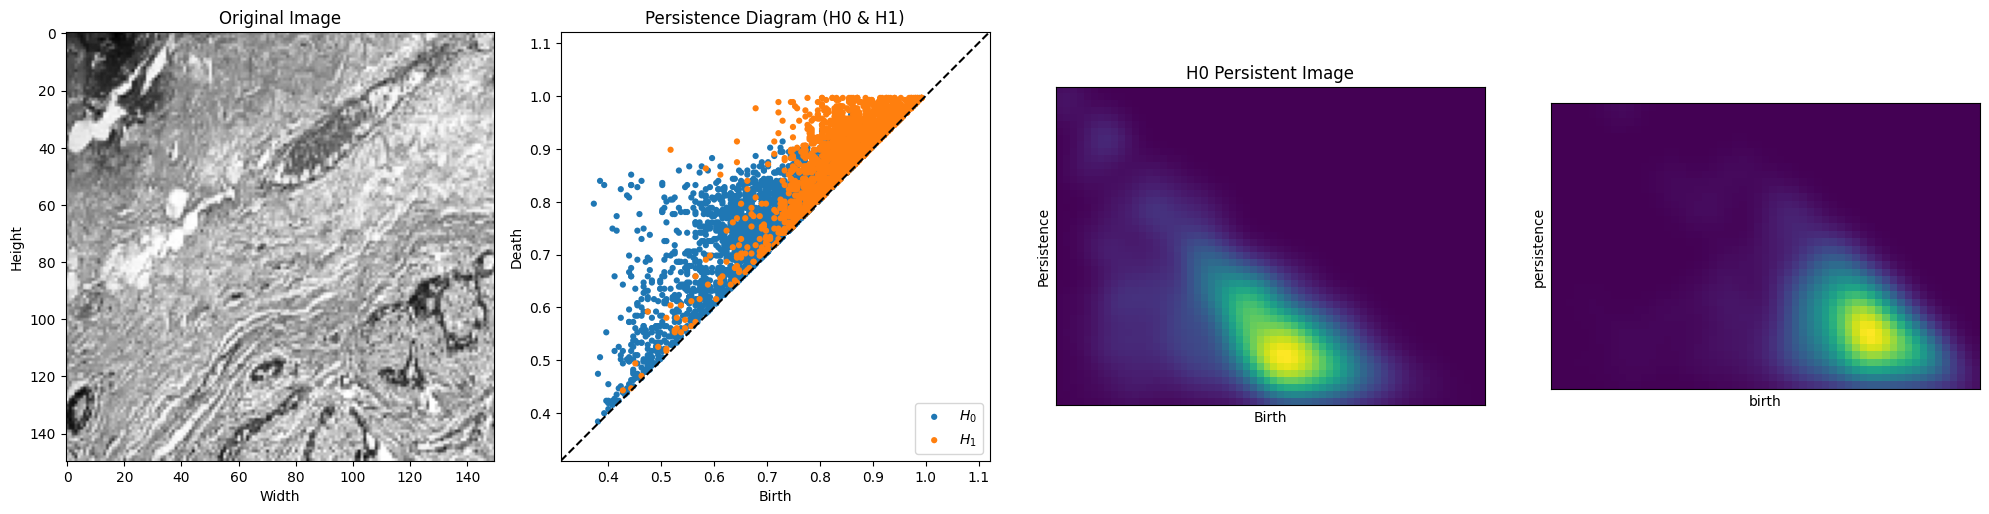

In [61]:
n = 123
pd_diagram = pds_40X[n]

fig, axs = plt.subplots(1, 4, figsize=(20, 5))  # 4 subplots now!

# Display original grayscale image
axs[0].imshow(X_40X[n], cmap="gray")
axs[0].set_title("Original Image")
axs[0].set_xlabel("Width")
axs[0].set_ylabel("Height")

persim.plot_diagrams(pd_diagram, ax=axs[1])
axs[1].set_title("Persistence Diagram (H0 & H1)")
axs[1].set_xlabel("Birth")
axs[1].set_ylabel("Death")

pimgr = PersistenceImager(pixel_size=0.01)
pimgr.fit(pd_diagram[0])
pimgr.kernel_params = {'sigma': .0005}
pimgr.plot_image(pimgr.transform(pd_diagram[0]), ax=axs[2])
axs[2].set_title("H0 Persistent Image")
axs[2].set_xlabel("Birth")
axs[2].set_ylabel("Persistence")

pimgr = PersistenceImager(pixel_size=0.01)
pimgr.fit(pd_diagram[1])
pimgr.kernel_params = {'sigma': .0005}
pimgr.plot_image(pimgr.transform(pd_diagram[1]), ax=axs[3])
axs[2].set_title("H0 Persistent Image")
axs[2].set_xlabel("Birth")
axs[2].set_ylabel("Persistence")

plt.tight_layout()
plt.show()

# Persistent Images and Random forest

## 40X and Random forest on Persistent Images

### Transforming data into Persistent images

In [57]:
pds_40X = []
for i in range(len(X_40X)):
    pd_diagram = cripser.computePH(X_40X[i], maxdim=1)  
    
    pd_diagram = [pd_diagram[pd_diagram[:, 0] == i, 1:3] for i in range(2)]

    pd_diagram_filtered = [
        pd_diagram[i][pd_diagram[i][:, 1] < 1]  # Keep only features where death < 1
        for i in range(2)
    ]
    pds_40X.append(pd_diagram_filtered)

In [47]:
persistent_images_h0 = []
persistent_images_h1 = []

for pd_diagram in pds_40X:
    pimgr = PersistenceImager(pixel_size=0.01)
    
    # For H0 (dimension 0),
    pimgr.fit(pd_diagram[0])  
    pimgr.kernel_params = {'sigma': 0.001}  
    pimgr_transformed_0 = pimgr.transform(pd_diagram[0])  
    
    # For H1 (dimension 1)
    pimgr.fit(pd_diagram[1]) 
    pimgr_transformed_1 = pimgr.transform(pd_diagram[1])  
    
    # Append the persistent images to the respective lists
    persistent_images_h0.append(pimgr_transformed_0)
    persistent_images_h1.append(pimgr_transformed_1)

### Random forest 

In [48]:
def resize_images(images, target_shape=(100, 100)):
    resized_images = []
    for img in images:
        resized_img = resize(img, target_shape, mode='reflect', anti_aliasing=True)
        resized_images.append(resized_img)
    return resized_images

# Resize all persistent images to a fixed size (100, 100)
persistent_images_h0_resized = resize_images(persistent_images_h0, target_shape=(100, 100))
persistent_images_h1_resized = resize_images(persistent_images_h1, target_shape=(100, 100)) 

# Function to flatten images from 2D to 1D
def flatten_images(images):
    return [img.flatten() for img in images]

# Flatten the resized images for both dimensions
pims_0_flat = flatten_images(persistent_images_h0_resized)
pims_1_flat = flatten_images(persistent_images_h1_resized)

# Convert to numpy arrays
pims_0_flat = np.array(pims_0_flat)
pims_1_flat = np.array(pims_1_flat)

In [49]:

X_train_0, X_test_0, y_train, y_test = train_test_split(pims_0_flat, y_40X, test_size=0.2, random_state=42)

scaler_0 = StandardScaler()
X_train_0 = scaler_0.fit_transform(X_train_0)
X_test_0 = scaler_0.transform(X_test_0)

clf_0 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_0.fit(X_train_0, y_train)

y_pred_0 = clf_0.predict(X_test_0)
accuracy_0 = accuracy_score(y_test, y_pred_0)
print(f"Accuracy: {accuracy_0:.4f}")
print("\nClassification Report (Dim 0):")
print(classification_report(y_test, y_pred_0))

print("\n=== Random Forest on Persistence Images (Dim 1) ===")
X_train_1, X_test_1, _, _ = train_test_split(pims_1_flat, y_40X, test_size=0.2, random_state=42)

# Scale the features
scaler_1 = StandardScaler()
X_train_1 = scaler_1.fit_transform(X_train_1)
X_test_1 = scaler_1.transform(X_test_1)

# Train Random Forest
clf_1 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_1.fit(X_train_1, y_train)

# Predict and Report
y_pred_1 = clf_1.predict(X_test_1)
accuracy_1 = accuracy_score(y_test, y_pred_1)
print(f"Accuracy: {accuracy_1:.4f}")
print("\nClassification Report (Dim 1):")
print(classification_report(y_test, y_pred_1))


Accuracy: 0.7870

Classification Report (Dim 0):
              precision    recall  f1-score   support

           0       0.76      0.54      0.63       134
           1       0.80      0.91      0.85       265

    accuracy                           0.79       399
   macro avg       0.78      0.73      0.74       399
weighted avg       0.78      0.79      0.78       399


=== Random Forest on Persistence Images (Dim 1) ===
Accuracy: 0.7644

Classification Report (Dim 1):
              precision    recall  f1-score   support

           0       0.73      0.47      0.57       134
           1       0.77      0.91      0.84       265

    accuracy                           0.76       399
   macro avg       0.75      0.69      0.71       399
weighted avg       0.76      0.76      0.75       399



In [50]:
# Flatten the images
# X_40X is a 3D array (num_images, height, width)
# We need to reshape it into 2D (num_images, height * width)
X_flat = X_40X.reshape(X_40X.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(X_flat, y_40X, test_size=0.3, random_state=42)

# Standardize the data (important for some classifiers like SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.6878
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.16      0.26       204
           1       0.69      0.96      0.80       395

    accuracy                           0.69       599
   macro avg       0.68      0.56      0.53       599
weighted avg       0.68      0.69      0.62       599



In [51]:
# Random forest on images alone

X_flat = np.array([img.ravel() for img in X_40X])  

combined_features = np.hstack([pims_0_flat, pims_1_flat, X_flat]) 

X_train, X_test, y_train, y_test = train_test_split(combined_features, y_40X, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier (Combined Features): {accuracy:.4f}")
print("\nClassification Report (Combined Features):")
print(classification_report(y_test, y_pred))

Accuracy of the Random Forest Classifier (Combined Features): 0.8120

Classification Report (Combined Features):
              precision    recall  f1-score   support

           0       0.85      0.54      0.66       134
           1       0.80      0.95      0.87       265

    accuracy                           0.81       399
   macro avg       0.82      0.74      0.76       399
weighted avg       0.82      0.81      0.80       399



In [52]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split data into train-test
X_train, X_test, y_train, y_test = train_test_split(combined_features, y_40X, test_size=0.2, random_state=42)

# Apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the data (important for many classifiers like SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train_resampled)

# Predict on the test set
y_pred = clf.predict(X_test_scaled)

# Print performance metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7920
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.60      0.66       134
           1       0.82      0.89      0.85       265

    accuracy                           0.79       399
   macro avg       0.77      0.75      0.76       399
weighted avg       0.79      0.79      0.79       399



## Other ML models

In [53]:
import numpy as np
from skimage.transform import resize

# Resize persistent images to a fixed size
def resize_persistent_images(images, target_shape=(100, 100)):
    resized_images = []
    for img in images:
        resized_img = resize(img, target_shape, mode='reflect', anti_aliasing=True)
        resized_images.append(resized_img)
    return resized_images

# Resize h0 and h1 images
persistent_images_h0_resized = resize_persistent_images(persistent_images_h0, target_shape=(100, 100))
persistent_images_h1_resized = resize_persistent_images(persistent_images_h1, target_shape=(100, 100))

# Stack h0 and h1 to create a 3-channel image
# You may combine them in various ways: here, we stack them as channels
combined_images = np.stack((persistent_images_h0_resized, persistent_images_h1_resized), axis=-1)

# Convert the list into a numpy array
combined_images = np.array(combined_images)

# Assuming you have labels (y_train, y_test), make sure they're correctly prepared
# For example, let's assume y_train and y_test are already given.


In [54]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from skimage.transform import resize

# Example of resizing the persistent images to 100x100
def resize_persistent_images(images, target_shape=(100, 100)):
    resized_images = []
    for img in images:
        resized_img = resize(img, target_shape, mode='reflect', anti_aliasing=True)
        resized_images.append(resized_img)
    return resized_images

# Resize persistent images
persistent_images_h0_resized = resize_persistent_images(persistent_images_h0, target_shape=(100, 100))
persistent_images_h1_resized = resize_persistent_images(persistent_images_h1, target_shape=(100, 100))

# Stack H0 and H1 to create a 3-channel image (assuming you want to combine them as channels)
combined_images = np.stack((persistent_images_h0_resized, persistent_images_h1_resized), axis=-1)

# Convert the list into a numpy array
combined_images = np.array(combined_images)

# Assuming y_40X are the labels corresponding to the persistent images
y = y_40X  # Your labels (assuming it's already prepared)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(combined_images, y, test_size=0.2, random_state=42)

# Define the number of output classes for your task
num_classes = 2  # Replace with the actual number of classes in your dataset

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 2)),  # 2 channels (H0 and H1)
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # num_classes should be the number of output classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert probabilities to class labels (using argmax to select the highest probability)
y_pred_classes = np.argmax(y_pred, axis=1)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"CNN Model Accuracy: {accuracy:.4f}")

# Generate the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 278ms/step - accuracy: 0.6918 - loss: 0.6091 - val_accuracy: 0.7444 - val_loss: 0.5618
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - accuracy: 0.7414 - loss: 0.5475 - val_accuracy: 0.7494 - val_loss: 0.5144
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - accuracy: 0.7655 - loss: 0.5032 - val_accuracy: 0.7719 - val_loss: 0.4792
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.7877 - loss: 0.4586 - val_accuracy: 0.7744 - val_loss: 0.4775
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 265ms/step - accuracy: 0.8097 - loss: 0.4397 - val_accuracy: 0.7368 - val_loss: 0.4723
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 266ms/step - accuracy: 0.8127 - loss: 0.4083 - val_accuracy: 0.7895 - val_loss: 0.4842
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - accuracy: 0.7929 - loss: 0.4310 - val_accuracy: 0.7945 - val_loss: 0.4862
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - accuracy: 0.8330 - loss: 0.3813 - val_accu

## Persistent Statistics

In [56]:
import numpy as np

def compute_persistent_statistics(pds):
    feature_vectors = []
    
    for pd_diagram_filtered in pds:
        features = []
        
        for dim in range(2):
            pd = pd_diagram_filtered[dim]
            
            birth_times = pd[:, 0]
            death_times = pd[:, 1]
            
            persistence_lengths = death_times - birth_times
            
            persistence_ratios = death_times / birth_times
            
            num_features = len(persistence_lengths)
            features.append(num_features)
            # Mean persistence length
            mean_persistence = np.mean(persistence_lengths) if num_features > 0 else 0
            features.append(mean_persistence)
            # Max persistence length
            max_persistence = np.max(persistence_lengths) if num_features > 0 else 0
            features.append(max_persistence)            
            # Std of persistence length
            std_persistence = np.std(persistence_lengths) if num_features > 0 else 0
            features.append(std_persistence)            
            # Mean persistence ratio
            mean_persistence_ratio = np.mean(persistence_ratios) if num_features > 0 else 0
            features.append(mean_persistence_ratio)            
            # Max persistence ratio
            max_persistence_ratio = np.max(persistence_ratios) if num_features > 0 else 0
            features.append(max_persistence_ratio)            
            # Std of persistence ratio
            std_persistence_ratio = np.std(persistence_ratios) if num_features > 0 else 0
            features.append(std_persistence_ratio)

        feature_vectors.append(features)
    
    feature_matrix = np.array(feature_vectors)
    
    return feature_matrix

X_persistent_statistics = compute_persistent_statistics(pds_40X)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_persistent_statistics, y_40X, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a classifier (e.g., Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate the classification report
print("\nClassification Report (Persistent Statistics):")
print(classification_report(y_test, y_pred))


Accuracy: 0.8170

Classification Report (Persistent Statistics):
              precision    recall  f1-score   support

           0       0.80      0.60      0.69       134
           1       0.82      0.92      0.87       265

    accuracy                           0.82       399
   macro avg       0.81      0.76      0.78       399
weighted avg       0.82      0.82      0.81       399



## 100X and Random forest on Persistent Images

In [60]:
pds_100X = []
for i in range(len(X_40X)):
    pd_diagram = cripser.computePH(X_40X[i], maxdim=1)  
    
    pd_diagram = [pd_diagram[pd_diagram[:, 0] == i, 1:3] for i in range(2)]

    pd_diagram_filtered = [
        pd_diagram[i][pd_diagram[i][:, 1] < 1]  # Keep only features where death < 1
        for i in range(2)
    ]
    pds_100X.append(pd_diagram_filtered)

X_pers_stats_100X = compute_persistent_statistics(pds_100X)

In [ ]:
persistent_images_100X_h0 = []
persistent_images_100X_h1 = []

for pd_diagram in pds:
    pimgr = PersistenceImager(pixel_size=0.01)
    
    # For H0 (dimension 0),
    pimgr.fit(pd_diagram[0])  
    pimgr.kernel_params = {'sigma': 0.001}  
    pimgr_transformed_0 = pimgr.transform(pd_diagram[0])  
    
    # For H1 (dimension 1)
    pimgr.fit(pd_diagram[1]) 
    pimgr_transformed_1 = pimgr.transform(pd_diagram[1])  
    
    persistent_images_100X_h0.append(pimgr_transformed_0)
    persistent_images_100X_h1.append(pimgr_transformed_1)

persistent_images_100X_h0_resized = resize_images(persistent_images_100X_h0, target_shape=(100, 100))
persistent_images_100X_h1_resized = resize_images(persistent_images_100X_h1, target_shape=(100, 100)) 

pims_0_flat_100X = flatten_images(persistent_images_100X_h0_resized)
pims_1_flat_100X = flatten_images(persistent_images_100X_h1_resized)

# Convert to numpy arrays
pims_0_flat_100X = np.array(pims_0_flat_100X)
pims_1_flat_100X = np.array(pims_1_flat_100X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pers_stats_100X, y_100X, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a classifier (e.g., Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate the classification report
print("\nClassification Report (Persistent Statistics):")
print(classification_report(y_test, y_pred))


In [ ]:
X_flat_100X = np.array([img.ravel() for img in X_100X])  

combined_features = np.hstack([pims_0_flat_100X, pims_1_flat_100X]) 

X_train, X_test, y_train, y_test = train_test_split(combined_features, y_100X, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier (Combined Features): {accuracy:.4f}")
print("\nClassification Report (Combined Features):")
print(classification_report(y_test, y_pred))

## 200X and Random forest on Persistent Images

In [20]:
pds_200X = []
for i in range(len(X_200X)):
    pd = cripser.computePH(dt(X_200X[i],signed=True))    # compute PH of distance transform
    pds_200X.append(pd)

max_life = 8
pixel_size = 1
pim = pimg.PersistenceImager(birth_range=(-max_life,max_life), pers_range=(0,max_life), pixel_size=pixel_size)

# vectorised PH of dimension 0
pims_200X_0 = []
for i in range(len(X_200X)):
    pd_200X = pds_200X[i]
    pd_200X[:,1:3] = np.clip(pd_200X[:,1:3],a_min=-max_life,a_max=max_life) # clip min/max birth/death
    pim0 = pim.transform(pd_200X[pd_200X[:,0]==0,1:3]) # vectorise PH by persistence image
    pims_200X_0.append(pim0.ravel())

# vectorised PH of dimension 1
pims_200X_1 = []
for i in range(len(X_200X)):
    pd_200X = pds_200X[i]
    pd_200X[:,1:3] = np.clip(pd_200X[:,1:3],a_min=-max_life,a_max=max_life) # clip min/max birth/death
    pim1 = pim.transform(pd_200X[pd_200X[:,0]==1,1:3]) # vectorise PH by persistence image
    pims_200X_1.append(pim1.ravel())

C:\Users\user\AppData\Local\Temp\ipykernel_16588\589798240.py:49: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (128, 128, 3) looks like that of an RGB image.
  bw_img = (img >= threshold_otsu(img))


In [22]:
pims_200X_0 = np.array(pims_200X_0)
pims_200X_0 = np.array(pims_200X_1)

labels = np.random.randint(0, 2, len(X_200X)) 

# train Random forest on dimension 0 
print("=== Random Forest on Persistence Images (Dim 0) ===")
X_200X_train_0, X_200X_test_0, y_200X_train, y_200X_test = train_test_split(pims_200X_0, y_200X, test_size=0.2, random_state=42)

scaler_0 = StandardScaler()
X_200X_train_0 = scaler_0.fit_transform(X_200X_train_0)
X_200X_test_0 = scaler_0.transform(X_200X_test_0)

clf_0 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_0.fit(X_200X_train_0, y_200X_train)

y_200X_pred_0 = clf_0.predict(X_200X_test_0)
accuracy_0 = accuracy_score(y_200X_test, y_200X_pred_0)
print(f"Accuracy: {accuracy_0:.4f}")
print("\nClassification Report (Dim 0):")
print(classification_report(y_200X_test, y_200X_pred_0))

print("\n=== Random Forest on Persistence Images (Dim 1) ===")
X_200X_train_1, X_200X_test_1, _, _ = train_test_split(pims_200X_1, y_200X, test_size=0.2, random_state=42)

# Scale the features
scaler_1 = StandardScaler()
X_200X_train_1 = scaler_1.fit_transform(X_200X_train_1)
X_200X_test_1 = scaler_1.transform(X_200X_test_1)

# Train Random Forest
clf_1 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_1.fit(X_200X_train_1, y_200X_train)

# Predict and Report
y_200X_pred_1 = clf_1.predict(X_200X_test_1)
accuracy_1 = accuracy_score(y_200X_test, y_200X_pred_1)
print(f"Accuracy: {accuracy_1:.4f}")
print("\nClassification Report (Dim 1):")
print(classification_report(y_200X_test, y_200X_pred_1))

=== Random Forest on Persistence Images (Dim 0) ===
Accuracy: 0.8462

Classification Report (Dim 0):
              precision    recall  f1-score   support

           0       0.88      0.64      0.74       137
           1       0.84      0.95      0.89       266

    accuracy                           0.85       403
   macro avg       0.86      0.79      0.81       403
weighted avg       0.85      0.85      0.84       403


=== Random Forest on Persistence Images (Dim 1) ===
Accuracy: 0.8462

Classification Report (Dim 1):
              precision    recall  f1-score   support

           0       0.88      0.64      0.74       137
           1       0.84      0.95      0.89       266

    accuracy                           0.85       403
   macro avg       0.86      0.79      0.81       403
weighted avg       0.85      0.85      0.84       403



## 400X and Random forest on Persistent Images

In [23]:
pds_400X = []
for i in range(len(X_400X)):
    pd = cripser.computePH(dt(X_400X[i],signed=True))    # compute PH of distance transform
    pds_400X.append(pd)

max_life = 8
pixel_size = 1
pim = pimg.PersistenceImager(birth_range=(-max_life,max_life), pers_range=(0,max_life), pixel_size=pixel_size)

# vectorised PH of dimension 0
pims_400X_0 = []
for i in range(len(X_400X)):
    pd_400X = pds_400X[i]
    pd_400X[:,1:3] = np.clip(pd_400X[:,1:3],a_min=-max_life,a_max=max_life) # clip min/max birth/death
    pim0 = pim.transform(pd_400X[pd_400X[:,0]==0,1:3]) # vectorise PH by persistence image
    pims_400X_0.append(pim0.ravel())

# vectorised PH of dimension 1
pims_400X_1 = []
for i in range(len(X_400X)):
    pd_400X = pds_400X[i]
    pd_400X[:,1:3] = np.clip(pd_400X[:,1:3],a_min=-max_life,a_max=max_life) # clip min/max birth/death
    pim1 = pim.transform(pd_400X[pd_400X[:,0]==1,1:3]) # vectorise PH by persistence image
    pims_400X_1.append(pim1.ravel())

C:\Users\user\AppData\Local\Temp\ipykernel_16588\589798240.py:49: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (128, 128, 3) looks like that of an RGB image.
  bw_img = (img >= threshold_otsu(img))


In [25]:
pims_400X_0 = np.array(pims_400X_0)
pims_400X_0 = np.array(pims_400X_1)

labels = np.random.randint(0, 2, len(X_400X)) 

# train Random forest on dimension 0 
print("=== Random Forest on Persistence Images (Dim 0) ===")
X_400X_train_0, X_400X_test_0, y_400X_train, y_400X_test = train_test_split(pims_400X_0, y_400X, test_size=0.2, random_state=42)

scaler_0 = StandardScaler()
X_400X_train_0 = scaler_0.fit_transform(X_400X_train_0)
X_400X_test_0 = scaler_0.transform(X_400X_test_0)

clf_0 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_0.fit(X_400X_train_0, y_400X_train)

y_400X_pred_0 = clf_0.predict(X_400X_test_0)
accuracy_0 = accuracy_score(y_400X_test, y_400X_pred_0)
print(f"Accuracy: {accuracy_0:.4f}")
print("\nClassification Report (Dim 0):")
print(classification_report(y_400X_test, y_400X_pred_0))

print("\n=== Random Forest on Persistence Images (Dim 1) ===")
X_400X_train_1, X_400X_test_1, _, _ = train_test_split(pims_400X_1, y_400X, test_size=0.2, random_state=42)

# Scale the features
scaler_1 = StandardScaler()
X_400X_train_1 = scaler_1.fit_transform(X_400X_train_1)
X_400X_test_1 = scaler_1.transform(X_400X_test_1)

# Train Random Forest
clf_1 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_1.fit(X_400X_train_1, y_400X_train)

# Predict and Report
y_400X_pred_1 = clf_1.predict(X_400X_test_1)
accuracy_1 = accuracy_score(y_400X_test, y_400X_pred_1)
print(f"Accuracy: {accuracy_1:.4f}")
print("\nClassification Report (Dim 1):")
print(classification_report(y_400X_test, y_400X_pred_1))

=== Random Forest on Persistence Images (Dim 0) ===
Accuracy: 0.8297

Classification Report (Dim 0):
              precision    recall  f1-score   support

           0       0.80      0.66      0.72       122
           1       0.84      0.92      0.88       242

    accuracy                           0.83       364
   macro avg       0.82      0.79      0.80       364
weighted avg       0.83      0.83      0.82       364


=== Random Forest on Persistence Images (Dim 1) ===
Accuracy: 0.8297

Classification Report (Dim 1):
              precision    recall  f1-score   support

           0       0.80      0.66      0.72       122
           1       0.84      0.92      0.88       242

    accuracy                           0.83       364
   macro avg       0.82      0.79      0.80       364
weighted avg       0.83      0.83      0.82       364

